# Validation exact-match failures — pipeline walkthrough

This notebook loads `validation_exact_failures.csv` from **`preprocess_sweep_glm_broad_v4`** only (config `gray_x3_lanczos`) and replays **frame → ROI → line boxes → crops → GLM-style preprocessing** for each affected DICOM so you can see **where** labels diverge from OCR.

**Paths:** DICOM locations are taken from `preprocess_sweep_glm_broad_v4/gray_x3_lanczos/label_scores.json`. If files moved, set `ECHO_OCR_DICOM_ROOT` or edit the resolver in the first code cell.

**Engine:** Uses **`glm-ocr`** with the same **`gray_x3_lanczos`** preprocess views as `sweep_preprocessing_headless.py` (`_build_preprocess_views`). If GLM cannot start, segmentation falls back to **no scout tokens** (visuals only; ordering can differ from the sweep).


In [1]:

from __future__ import annotations

import csv
import json
import os
import sys
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def find_repo(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "app" / "pipeline" / "echo_ocr_pipeline.py").is_file():
            return p
    raise RuntimeError("Run this notebook from the Master repo.")


REPO = find_repo(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from app.validation.datasets import resolve_dataset_path

_ARTIFACT = REPO / "artifacts" / "ocr_redesign"
LABEL_SCORES = _ARTIFACT / "preprocess_sweep_glm_broad_v4" / "gray_x3_lanczos" / "label_scores.json"
if not LABEL_SCORES.is_file():
    raise FileNotFoundError(
        f"Missing {LABEL_SCORES} — run the v4 GLM sweep and export_validation_failures.py first."
    )
FAILURES_CSV = LABEL_SCORES.parent.parent / "validation_exact_failures.csv"


def resolve_label_score_path(file_record: dict[str, object]) -> Path:
    return resolve_dataset_path(file_record, LABEL_SCORES)


ls = json.loads(LABEL_SCORES.read_text(encoding="utf-8"))
if FAILURES_CSV.is_file():
    with FAILURES_CSV.open(encoding="utf-8", newline="") as f:
        rows = list(csv.DictReader(f))
else:
    rows = []
    for fd in ls["file_details"]:
        if fd.get("split") != "validation":
            continue
        resolved_path = resolve_label_score_path(fd)
        fname = fd.get("file_name") or resolved_path.name
        for i, m in enumerate(fd.get("matches") or []):
            if m.get("full_match", True):
                continue
            rows.append(
                {
                    "file_name": fname,
                    "line_index_in_matches": str(i),
                    "expected_text": m.get("expected_text", ""),
                    "predicted_text": m.get("predicted_text") or "",
                    "line_match": str(m.get("line_match", "")),
                    "value_match": str(m.get("value_match", "")),
                    "label_match": str(m.get("label_match", "")),
                }
            )
    print("(built failure list from label_scores; run export_validation_failures.py to write CSV)")
path_by_name: dict[str, Path] = {}
for fd in ls["file_details"]:
    if fd.get("split") != "validation":
        continue
    resolved_path = resolve_label_score_path(fd)
    path_by_name[resolved_path.name] = resolved_path

extra_root = os.environ.get("ECHO_OCR_DICOM_ROOT", "").strip()
if extra_root:
    root = Path(extra_root).expanduser().resolve()
    for name in list(path_by_name.keys()):
        p = path_by_name[name]
        if not p.is_file():
            hits = list(root.rglob(name))
            if hits:
                path_by_name[name] = hits[0]

by_file: dict[str, list[dict[str, str]]] = defaultdict(list)
for row in rows:
    by_file[row["file_name"]].append(row)
by_file = dict(sorted(by_file.items()))

print("REPO:", REPO)
print("Failure rows:", len(rows), "| Unique DICOMs:", len(by_file))
for name in sorted(by_file.keys()):
    p = path_by_name.get(name)
    ok = p.is_file() if p else False
    print(f"  {name} ->", p if ok else (p, "MISSING"))


REPO: C:\Users\G513\Documents\howest\Semester_5\Stage\StageOpdracht\Master
Failure rows: 1 | Unique DICOMs: 1
  91243943_0053.dcm -> C:\Users\G513\Documents\howest\Semester_5\Stage\StageOpdracht\database_stage\files\p10\p10003731\s91243943\91243943_0053.dcm


In [2]:

from app.pipeline.ai_pipeline import PipelineConfig
from app.pipeline.layout.echo_ocr_box_detector import TopLeftBlueGrayBoxDetector, _color_match_mask
from app.pipeline.echo_ocr_pipeline import EchoOcrPipeline
from app.pipeline.ocr.ocr_engines import UnavailableOcrEngineError, build_engine
from app.tools.batch.sweep_preprocessing_headless import _broad_configs, _build_preprocess_views

detector = TopLeftBlueGrayBoxDetector()
sweep_cfg = next(c for c in _broad_configs() if c.name == "gray_x3_lanczos")
preprocess_views = _build_preprocess_views(sweep_cfg)

pipe: EchoOcrPipeline | None
pipe = None
try:
    pipe = EchoOcrPipeline(
        ocr_engine=build_engine("glm-ocr"),
        config=PipelineConfig(
            parameters={
                "ocr_engine": "glm-ocr",
                "requested_ocr_engine": "glm-ocr",
                "parser_mode": "off",
            }
        ),
    )
    pipe.ensure_components()
    pipe._line_transcriber.preprocess_views = preprocess_views
    print("Pipeline: glm-ocr +", sweep_cfg.name)
except (UnavailableOcrEngineError, Exception) as exc:
    print("GLM pipeline unavailable:", exc)
    print("Figures will use segmentation without scout tokens (fallback).")


Pipeline: glm-ocr + gray_x3_lanczos


In [3]:

def run_inspection(dicom_path: Path, fail_rows: list[dict[str, str]]) -> None:
    from app.io.dicom_loader import load_dicom_series
    from app.ocr.preprocessing import preprocess_gray_x3_lanczos
    from app.pipeline.echo_ocr_pipeline import (
        DEFAULT_SEGMENTATION_EXTRA_LEFT_PAD_PX,
        DEFAULT_SEGMENTATION_MODE,
        DEFAULT_TARGET_LINE_HEIGHT_PX,
    )
    from app.pipeline.layout.line_segmenter import LineSegmenter
    from app.pipeline.transcription.line_transcriber import crop_segment

    series = load_dicom_series(dicom_path, load_pixels=True)
    frame = series.raw_frames[0]

    detection = detector.detect(frame)
    if not detection.present or detection.bbox is None:
        print("ROI not found for", dicom_path.name)
        return

    x, y, bw, bh = detection.bbox
    rgb = frame[..., :3].astype(np.int16)
    mask = _color_match_mask(rgb, detector.box_color, detector.color_tolerance).astype(np.uint8) * 255
    overlay = frame.copy()
    cv2.rectangle(overlay, (x, y), (x + bw, y + bh), (0, 255, 0), 2)

    roi = frame[y : y + bh, x : x + bw].copy()
    segmentation = None
    panel = None
    measurements = []

    if pipe is not None:
        _det, segmentation, _ocr, panel, measurements, _bbox = pipe.analyze_frame_with_debug(frame)
    else:
        segmenter = LineSegmenter(
            segmentation_mode=DEFAULT_SEGMENTATION_MODE,
            target_line_height_px=DEFAULT_TARGET_LINE_HEIGHT_PX,
            extra_left_pad_px=DEFAULT_SEGMENTATION_EXTRA_LEFT_PAD_PX,
        )
        segmentation = segmenter.segment(roi, tokens=None)

    usable_segments = list(segmentation.lines)
    line_crops = [crop_segment(roi, seg) for seg in usable_segments]
    match_ixs = sorted({int(r["line_index_in_matches"]) for r in fail_rows})
    match_to_panel_ix: dict[int, int] = {}
    for match_ix, measurement in enumerate(measurements):
        panel_ix = measurement.order_hint
        if panel_ix is None:
            continue
        panel_ix = int(panel_ix)
        if 0 <= panel_ix < len(usable_segments):
            match_to_panel_ix[match_ix] = panel_ix
    bad_panel_ix = {match_to_panel_ix[ix] for ix in match_ixs if ix in match_to_panel_ix}
    unmapped_match_ixs = [ix for ix in match_ixs if ix not in match_to_panel_ix]

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 3, height_ratios=[1.0, 1.2, 0.9])

    ax0 = fig.add_subplot(gs[0, :])
    ax0.imshow(frame)
    ax0.set_title(f"{dicom_path.name} — 1 Full frame")
    ax0.axis("off")

    ax1 = fig.add_subplot(gs[1, 0])
    ax1.imshow(mask, cmap="gray")
    ax1.set_title("2a Max channel |Δ| to box color (≤ tolerance = match)")
    ax1.axis("off")
    ax2 = fig.add_subplot(gs[1, 1])
    ax2.imshow(overlay)
    ax2.set_title("2b ROI box")
    ax2.axis("off")
    ax3 = fig.add_subplot(gs[1, 2])
    ax3.imshow(roi)
    ax3.set_title("3 Cropped ROI")
    ax3.axis("off")

    vis = roi.copy()
    for idx, line in enumerate(usable_segments):
        lx, ly, lw, lh = line.bbox
        col = (255, 64, 64) if idx in bad_panel_ix else (255, 0, 0)
        th = 2 if idx in bad_panel_ix else 1
        cv2.rectangle(vis, (lx, ly), (lx + lw, ly + lh), col, th)
        cv2.putText(
            vis,
            str(idx),
            (lx, max(0, ly - 2)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            col,
            1,
            cv2.LINE_AA,
        )
    ax4 = fig.add_subplot(gs[2, :])
    ax4.imshow(vis)
    ax4.set_title("4 Line boxes (thicker red = panel lines linked to failing CSV matches)")
    ax4.axis("off")

    plt.suptitle(dicom_path.name, fontsize=11)
    plt.tight_layout()
    plt.show()

    if unmapped_match_ixs:
        print(f"  warning: could not map match indexes to panel lines: {unmapped_match_ixs}")

    n = len(line_crops)
    if n == 0:
        print("  no measurement lines after segmentation")
    else:
        cols = min(4, n)
        rows = (n + cols - 1) // cols
        fig2, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 2.4 * rows))
        axes = np.atleast_1d(axes).ravel()
        for i, crop in enumerate(line_crops):
            axes[i].imshow(crop)
            title = f"Line {i}"
            if i in bad_panel_ix:
                title = f"FAIL {i}"
            axes[i].set_title(title, fontsize=8, color=("red" if i in bad_panel_ix else "black"))
            axes[i].axis("off")
        for j in range(n, len(axes)):
            axes[j].axis("off")
        plt.suptitle(f"{dicom_path.name} — 5 Raw line crops", fontsize=10)
        plt.tight_layout()
        plt.show()

    for panel_ix in sorted(bad_panel_ix):
        if panel_ix >= len(line_crops):
            print(f"  panel line index {panel_ix} out of range (only {len(line_crops)} lines)")
            continue
        proc = preprocess_gray_x3_lanczos(line_crops[panel_ix])
        fig3, ax = plt.subplots(1, 1, figsize=(8, 2.5))
        ax.imshow(proc, cmap="gray")
        ocr_txt = ""
        if panel is not None and panel_ix < len(panel.lines):
            ocr_txt = panel.lines[panel_ix].text or ""
        ax.set_title(
            f"Panel line {panel_ix} — preprocess_gray_x3_lanczos | OCR line: {ocr_txt!r}",
            fontsize=8,
        )
        ax.axis("off")
        plt.tight_layout()
        plt.show()

    print("--- Label CSV vs OCR line text ---")
    for row in fail_rows:
        match_ix = int(row["line_index_in_matches"])
        exp = row["expected_text"]
        pred = row["predicted_text"]
        panel_ix = match_to_panel_ix.get(match_ix)
        ocr_line = ""
        if panel is not None and panel_ix is not None and panel_ix < len(panel.lines):
            ocr_line = panel.lines[panel_ix].text or ""
        print(f"  match index {match_ix}:")
        print(f"    panel line index: {panel_ix if panel_ix is not None else 'unavailable'}")
        print(f"    expected (label):  {exp!r}")
        print(f"    predicted (eval):  {pred!r}")
        print(f"    OCR line (panel): {ocr_line!r}")
    print()


## Run all failure files

Set `ONLY_NAMES` to restrict to a subset (e.g. one study for a meeting).

C:\Users\G513\Documents\howest\Semester_5\Stage\StageOpdracht\database_stage\files\p10\p10003731\s91243943\91243943_0053.dcm


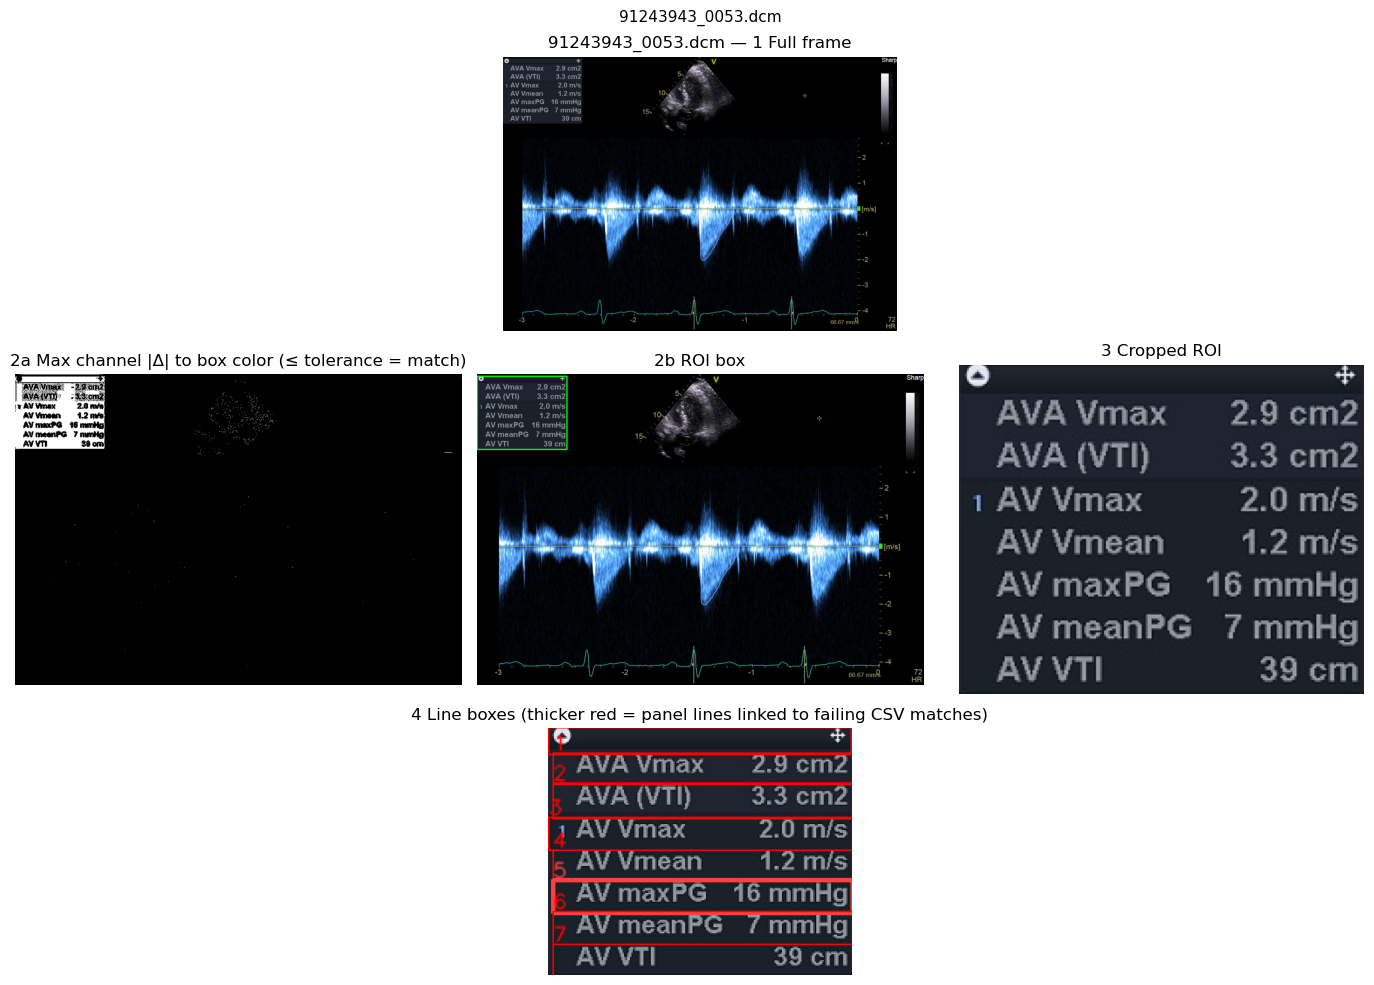

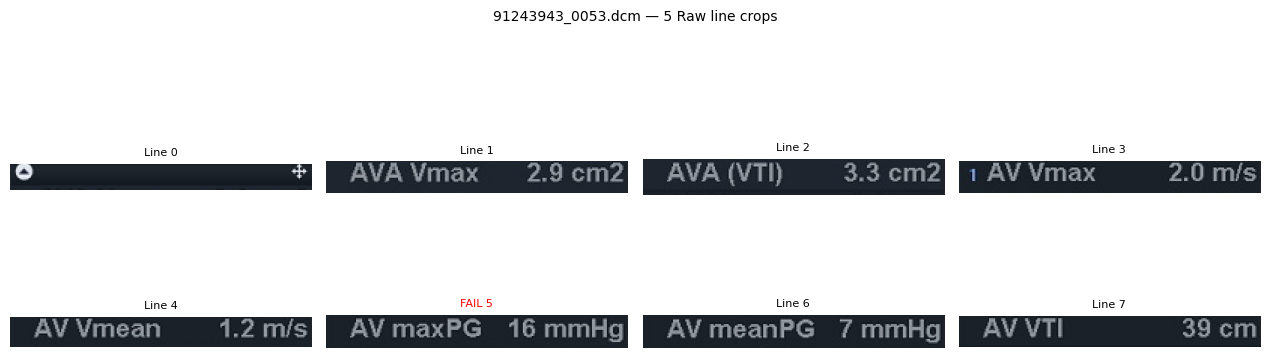

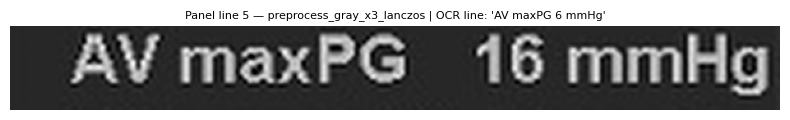

--- Label CSV vs OCR line text ---
  match index 4:
    panel line index: 5
    expected (label):  'AV maxPG 16 mmHg'
    predicted (eval):  'AV maxPG 6 mmHg'
    OCR line (panel): 'AV maxPG 6 mmHg'



In [4]:

ONLY_NAMES: set[str] | None = None  # e.g. {"92290733_0035.dcm"}

names = sorted(by_file.keys())
if ONLY_NAMES is not None:
    names = [n for n in names if n in ONLY_NAMES]

for name in names:
    p = path_by_name.get(name)
    if p is None or not p.is_file():
        print("Skip (path missing):", name, p)
        continue
    print("=" * 72)
    print(p)
    run_inspection(p, by_file[name])
